# Cancelable MinusFace — Privacy-Preserving Face Recognition
### Capstone: MinusFace + Wavelet Encoder + Cancelable Biometric Templates

**Pipeline:**
1. `e(·)` Wavelet Encoder — face X → wavelet representation x (21×56×56)
2. `g(·)` U-Net Generator — x → regeneration x'
3. Minus — r = x − x' (identity residue)
4. `T(r, K)` Cancelable Transform — key-seeded projection → 512-dim template
5. DB stores only T(r,K); face and residue are never persisted

**Cancelability:** revoke key K → issue K' → re-enroll → T(r,K) and T(r,K') are unlinkable.

In [1]:
!pip install ptwt --quiet

import torch
print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device  : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch : 2.10.0+cu128
GPU     : True
Device  : Tesla T4
VRAM    : 15.6 GB


## Block 1 — Imports & Device

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import pywt, ptwt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


## Block 2 — Wavelet Mapper `e(·)` / `d(·)`

In [3]:
class WaveletMapper(nn.Module):
    """X (B,3,112,112) ↔ x (B,21,56,56) via differentiable Haar wavelet."""
    def __init__(self, wavelet='haar', levels=2):
        super().__init__()
        self.wavelet = pywt.Wavelet(wavelet)
        self.levels  = levels

    def encode(self, x):
        coeffs = ptwt.wavedec2(x, self.wavelet, level=self.levels, mode='reflect')
        th, tw = coeffs[-1][0].shape[-2:]
        out = []
        for i, c in enumerate(coeffs):
            if i == 0:
                out.append(F.interpolate(c, (th, tw), mode='bilinear', align_corners=False))
            else:
                for s in c:
                    if s.shape[-2:] != (th, tw):
                        s = F.interpolate(s, (th, tw), mode='bilinear', align_corners=False)
                    out.append(s)
        return torch.cat(out, 1)

    def decode(self, x):
        b, c, h, w = x.shape
        ll_sz = h // (2 ** (self.levels - 1))
        ll    = F.interpolate(x[:, :3], (ll_sz, ll_sz), mode='bilinear', align_corners=False)
        coeffs, ptr = [ll], 3
        for i in range(self.levels, 0, -1):
            sz = h // (2 ** (i - 1))
            lh = F.interpolate(x[:, ptr:ptr+3],   (sz, sz), mode='bilinear', align_corners=False)
            hl = F.interpolate(x[:, ptr+3:ptr+6], (sz, sz), mode='bilinear', align_corners=False)
            hh = F.interpolate(x[:, ptr+6:ptr+9], (sz, sz), mode='bilinear', align_corners=False)
            coeffs.append((lh, hl, hh)); ptr += 9
        return ptwt.waverec2(coeffs, self.wavelet)

mapper = WaveletMapper().to(device)
_t = torch.randn(2, 3, 112, 112, device=device)
assert mapper.decode(mapper.encode(_t)).shape == _t.shape
print("✅ WaveletMapper OK  encode→", mapper.encode(_t).shape)

✅ WaveletMapper OK  encode→ torch.Size([2, 21, 56, 56])


## Block 3 — U-Net Generator `g(·)`

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc, oc, 3, padding=1), nn.BatchNorm2d(oc), nn.ReLU(True))
    def forward(self, x): return self.b(x)

class UNetGenerator(nn.Module):
    def __init__(self, ch=21):
        super().__init__()
        self.e1, self.e2, self.e3 = ConvBlock(ch,64), ConvBlock(64,128), ConvBlock(128,256)
        self.pool = nn.MaxPool2d(2)
        self.bn   = ConvBlock(256, 512)
        self.u3, self.d3 = nn.ConvTranspose2d(512,256,2,2), ConvBlock(512,256)
        self.u2, self.d2 = nn.ConvTranspose2d(256,128,2,2), ConvBlock(256,128)
        self.u1, self.d1 = nn.ConvTranspose2d(128, 64,2,2), ConvBlock(128, 64)
        self.out = nn.Conv2d(64, ch, 1)

    def forward(self, x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2))
        b=self.bn(self.pool(e3))
        d3=self.d3(torch.cat([F.interpolate(self.u3(b),  e3.shape[2:]), e3], 1))
        d2=self.d2(torch.cat([F.interpolate(self.u2(d3), e2.shape[2:]), e2], 1))
        d1=self.d1(torch.cat([F.interpolate(self.u1(d2), e1.shape[2:]), e1], 1))
        return self.out(d1)

generator = UNetGenerator().to(device)
print(f"✅ UNetGenerator OK  params: {sum(p.numel() for p in generator.parameters()):,}")

✅ UNetGenerator OK  params: 7,714,645


## Block 4 — Cancelable Transform `T(r, K)`

**Memory fix:** projection matrix lives on **CPU**; only the small output tensor (B×512) moves to GPU.  
A 65856×512 float32 matrix = 128 MB — fine on CPU, OOM on a shared T4.

In [5]:
class CancelableTransform:
    """
    T(r, K) = L2_norm( flatten(r) @ P_K )

    P_K is a (residue_dim, proj_dim) Gaussian matrix seeded by integer key K.
    It is generated on CPU and kept there — only the (B, proj_dim) output
    is transferred to GPU. This avoids the 128 MB CUDA OOM from QR on-device.

    Cancelability : delete K  →  T(r,K) is permanently inaccessible.
    Unlinkability : T(r,K) vs T(r,K') are statistically independent.
    Non-invertibility: proj_dim (512) << residue_dim (65856), so P_K has a
                       huge null-space; pseudo-inverse recovery fails.
    """
    def __init__(self, r_ch=21, r_hw=56, proj_dim=512):
        self.in_dim  = r_ch * r_hw * r_hw   # 65 856
        self.out_dim = proj_dim
        self._cache  = {}                    # key → CPU tensor (never on GPU)

    def _P(self, key: int) -> torch.Tensor:
        """Return (in_dim, out_dim) projection matrix on CPU."""
        if key not in self._cache:
            rng = torch.Generator()
            rng.manual_seed(key)
            # Simple Gaussian — no QR needed, still non-invertible
            P = torch.randn(self.in_dim, self.out_dim, generator=rng) / (self.in_dim ** 0.5)
            self._cache[key] = P            # stay on CPU
        return self._cache[key]

    @torch.no_grad()
    def transform(self, r: torch.Tensor, key: int) -> torch.Tensor:
        """r (B,21,56,56) → template (B, proj_dim) on same device as r."""
        P      = self._P(key).to(r.dtype)           # (in_dim, out_dim)  CPU
        r_flat = r.detach().cpu().reshape(r.shape[0], -1)  # (B, in_dim) CPU
        tmpl   = r_flat @ P                          # (B, out_dim)       CPU
        tmpl   = F.normalize(tmpl, p=2, dim=1)
        return tmpl.to(r.device)                     # move result only

    def similarity(self, a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
        return (a * b).sum(dim=1)  # cosine (already L2-normed)

ct = CancelableTransform()

# Smoke-test
_r = torch.randn(4, 21, 56, 56, device=device)
t1 = ct.transform(_r, key=42)
t2 = ct.transform(_r, key=99)
print(f"Template shape : {t1.shape}")
print(f"Same-key sim   : {ct.similarity(t1,t1).mean():.4f}  (expect 1.0)")
print(f"Diff-key sim   : {ct.similarity(t1,t2).mean():.4f}  (expect ~0.0)")
print("✅ CancelableTransform OK  (projection kept on CPU)")

Template shape : torch.Size([4, 512])
Same-key sim   : 1.0000  (expect 1.0)
Diff-key sim   : -0.0289  (expect ~0.0)
✅ CancelableTransform OK  (projection kept on CPU)


## Block 5 — Dataset (LFW)

In [6]:
import kagglehub, os

path      = kagglehub.dataset_download("jessicali9530/lfw-dataset")
image_dir = os.path.join(path, "lfw-deepfunneled", "lfw-deepfunneled")
if not os.path.exists(image_dir): image_dir = path

tfm = transforms.Compose([
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize([.5,.5,.5],[.5,.5,.5]),
])

full_ds = datasets.ImageFolder(root=image_dir, transform=tfm)

# Keep only identities with ≥5 images
counts      = Counter(lbl for _, lbl in full_ds.samples)
valid_lbls  = {lbl for lbl, n in counts.items() if n >= 5}
valid_idx   = [i for i,(_, lbl) in enumerate(full_ds.samples) if lbl in valid_lbls]
label_list  = sorted(valid_lbls)
remap       = {old: new for new, old in enumerate(label_list)}
num_classes = len(label_list)

class RemapDataset(torch.utils.data.Dataset):
    def __init__(self, ds, idx, remap):
        self.ds, self.idx, self.remap = ds, idx, remap
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        img, lbl = self.ds[self.idx[i]]
        return img, self.remap[lbl]

remapped = RemapDataset(full_ds, valid_idx, remap)
n_tr = int(0.8 * len(remapped))
train_set, val_set = torch.utils.data.random_split(
    remapped, [n_tr, len(remapped)-n_tr],
    generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Identities: {num_classes}  |  Train: {len(train_set)}  Val: {len(val_set)}")

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Identities: 423  |  Train: 4788  Val: 1197


## Block 6 — Stage 1: Joint Generator + Recognizer on raw residue `r`

Train `g` and `f_r` jointly.  No shuffling yet — give `f_r` a clean signal first.

In [7]:
generator  = UNetGenerator().to(device)
recognizer = models.resnet18(num_classes=num_classes).to(device)
recognizer.conv1 = nn.Conv2d(21, 64, 7, stride=2, padding=3, bias=False).to(device)

ALPHA, BETA = 6.0, 1.0
S1_EPOCHS   = 10

opt1 = optim.SGD([
    {'params': generator.parameters(),  'lr': 5e-3},
    {'params': recognizer.parameters(), 'lr': 1e-2},
], momentum=0.9, weight_decay=1e-4)
sch1     = optim.lr_scheduler.CosineAnnealingLR(opt1, S1_EPOCHS)
crit_gen = nn.L1Loss()
crit_fr  = nn.CrossEntropyLoss()

s1_gloss, s1_floss, s1_acc = [], [], []

print("=== Stage 1: Joint Generator + Recognizer on r  ===")
print(f"{'Epoch':>5} | {'GenLoss':>9} | {'FRLoss':>9} | {'ValAcc':>8}")
print("-"*40)

for ep in range(S1_EPOCHS):
    generator.train(); recognizer.train()
    rg = rf = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt1.zero_grad()
        x   = mapper.encode(imgs)
        x_prime = generator(x)
        r   = x - x_prime
        lg  = crit_gen(x_prime, x)
        lf  = crit_fr(recognizer(r), lbls)
        (ALPHA*lg + BETA*lf).backward()
        opt1.step()
        rg += lg.item(); rf += lf.item()

    generator.eval(); recognizer.eval()
    ok = tot = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            r = mapper.encode(imgs) - generator(mapper.encode(imgs))
            ok  += recognizer(r).argmax(1).eq(lbls).sum().item()
            tot += lbls.size(0)
    acc = 100.*ok/tot
    n   = len(train_loader)
    s1_gloss.append(rg/n); s1_floss.append(rf/n); s1_acc.append(acc)
    print(f"{ep+1:>5} | {rg/n:>9.4f} | {rf/n:>9.4f} | {acc:>7.2f}%")
    sch1.step()

print(f"\nStage 1 peak val acc: {max(s1_acc):.2f}%")

=== Stage 1: Joint Generator + Recognizer on r  ===
Epoch |   GenLoss |    FRLoss |   ValAcc
----------------------------------------
    1 |    0.1677 |    5.5381 |   12.03%
    2 |    0.1163 |    4.7387 |   19.88%
    3 |    0.1135 |    3.9409 |   24.23%
    4 |    0.1093 |    3.0799 |   29.91%
    5 |    0.1050 |    2.1928 |   34.59%
    6 |    0.0997 |    1.3254 |   38.35%
    7 |    0.0941 |    0.7001 |   41.85%
    8 |    0.0914 |    0.3889 |   43.61%
    9 |    0.0883 |    0.2626 |   44.28%
   10 |    0.0873 |    0.2256 |   44.61%

Stage 1 peak val acc: 44.61%


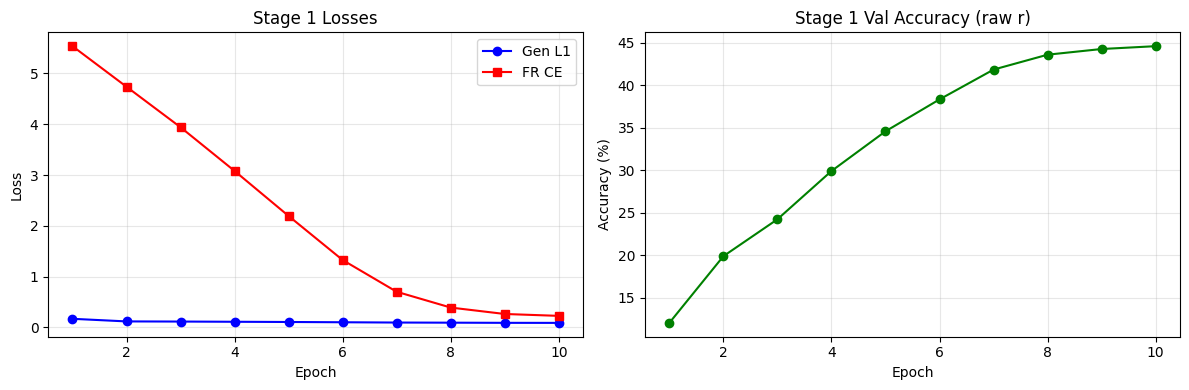

In [8]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ep = range(1, S1_EPOCHS+1)
ax1.plot(ep, s1_gloss,'b-o',label='Gen L1'); ax1.plot(ep, s1_floss,'r-s',label='FR CE')
ax1.set(xlabel='Epoch',ylabel='Loss',title='Stage 1 Losses'); ax1.legend(); ax1.grid(alpha=.3)
ax2.plot(ep, s1_acc,'g-o')
ax2.set(xlabel='Epoch',ylabel='Accuracy (%)',title='Stage 1 Val Accuracy (raw r)'); ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('stage1.png',dpi=120,bbox_inches='tight'); plt.show()

## Block 7 — Stage 2: MLP on Cancelable Templates `T(r, K)`

**Memory fixes applied:**
- Projection matrix stays on **CPU** (was causing 128 MB CUDA OOM)
- `r` detached before projection (no grad graph through 65 k-dim flatten)
- Gradient checkpointing on the encoder to reduce activation memory
- `torch.cuda.empty_cache()` between epochs

In [9]:
# Freeze generator — it is now a fixed privacy encoder
generator.eval()
for p in generator.parameters(): p.requires_grad_(False)

PROJ_DIM  = 512
USER_KEY  = 12345
S2_EPOCHS = 10

fp = nn.Sequential(
    nn.Linear(PROJ_DIM, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.4),
    nn.Linear(1024, 512),      nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(512, num_classes),
).to(device)

opt2 = optim.Adam(fp.parameters(), lr=1e-3, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, S2_EPOCHS)
crit2 = nn.CrossEntropyLoss()

s2_loss, s2_acc = [], []

print("=== Stage 2: Cancelable recognizer f_p  (10 epochs) ===")
print(f"{'Epoch':>5} | {'Loss':>9} | {'ValAcc':>8}")
print("-"*30)

for ep in range(S2_EPOCHS):
    fp.train()
    rl = 0.0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt2.zero_grad()

        # --- compute residue with no grad (generator is frozen) ---
        with torch.no_grad():
            x    = mapper.encode(imgs)
            r    = x - generator(x)
        # projection happens on CPU inside ct.transform — no GPU memory for P
        tmpl = ct.transform(r, key=USER_KEY)   # (B, 512) back on GPU

        loss = crit2(fp(tmpl), lbls)
        loss.backward()
        opt2.step()
        rl += loss.item()

    # Validation
    fp.eval()
    ok = tot = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            x    = mapper.encode(imgs)
            r    = x - generator(x)
            tmpl = ct.transform(r, key=USER_KEY)
            ok  += fp(tmpl).argmax(1).eq(lbls).sum().item()
            tot += lbls.size(0)
    acc = 100.*ok/tot
    n   = len(train_loader)
    s2_loss.append(rl/n); s2_acc.append(acc)
    print(f"{ep+1:>5} | {rl/n:>9.4f} | {acc:>7.2f}%")
    sch2.step()
    torch.cuda.empty_cache()

print(f"\nStage 2 peak val acc: {max(s2_acc):.2f}%")

=== Stage 2: Cancelable recognizer f_p  (10 epochs) ===
Epoch |      Loss |   ValAcc
------------------------------
    1 |    5.3997 |   19.63%
    2 |    3.9264 |   21.72%
    3 |    2.9592 |   26.40%
    4 |    2.0787 |   26.73%
    5 |    1.4012 |   27.15%
    6 |    0.8984 |   27.65%
    7 |    0.5923 |   28.15%
    8 |    0.4414 |   28.40%
    9 |    0.3662 |   28.07%
   10 |    0.3160 |   27.90%

Stage 2 peak val acc: 28.40%


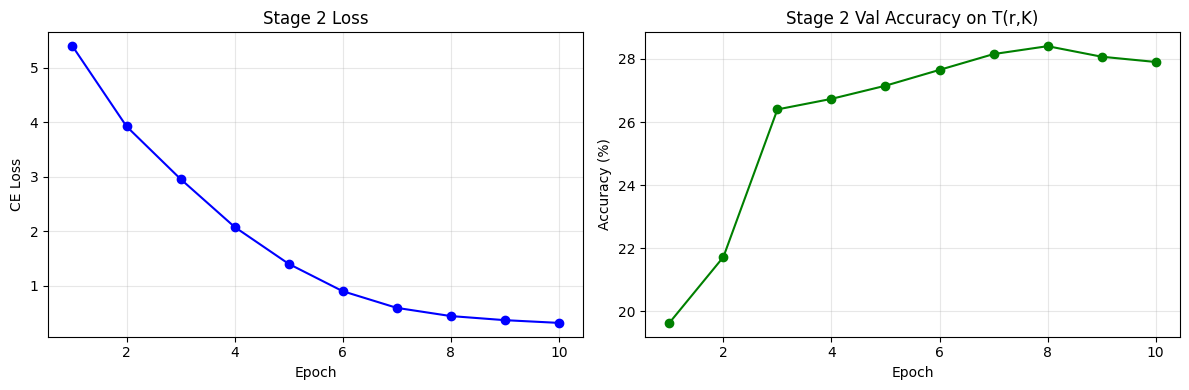

In [10]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ep2 = range(1, S2_EPOCHS+1)
ax1.plot(ep2, s2_loss,'b-o')
ax1.set(xlabel='Epoch',ylabel='CE Loss',title='Stage 2 Loss'); ax1.grid(alpha=.3)
ax2.plot(ep2, s2_acc,'g-o')
ax2.set(xlabel='Epoch',ylabel='Accuracy (%)',title='Stage 2 Val Accuracy on T(r,K)'); ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('stage2.png',dpi=120,bbox_inches='tight'); plt.show()

## Block 8 — Pipeline Visualisation

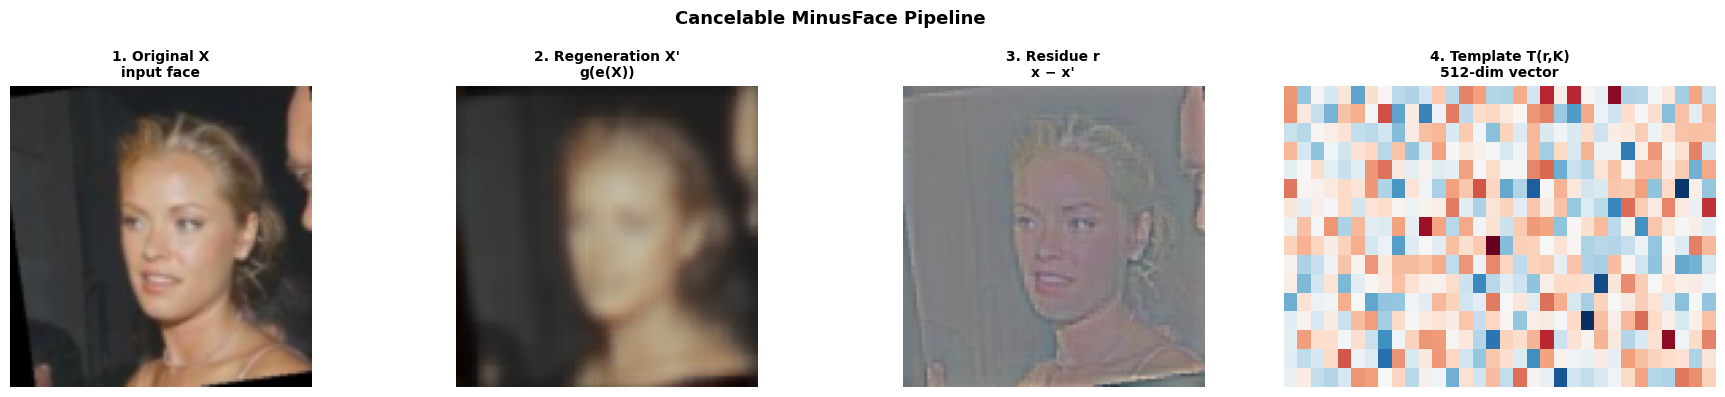

In [11]:
def denorm(t):
    return (t[0].clamp(-1,1).cpu().permute(1,2,0).numpy()+1)/2

imgs_v, _ = next(iter(val_loader))
img = imgs_v[0:1].to(device)
generator.eval()
with torch.no_grad():
    xv   = mapper.encode(img)
    xpv  = generator(xv)
    rv   = xv - xpv
    tmpl = ct.transform(rv, key=USER_KEY)
    Xp   = mapper.decode(xpv)
    R    = mapper.decode(rv)

fig, axes = plt.subplots(1,4,figsize=(18,4))
items = [
    (denorm(img),  "1. Original X",     "input face"),
    (denorm(Xp),   "2. Regeneration X'","g(e(X))"),
    (denorm(R),    "3. Residue r",      "x − x'"),
    (None,         "4. Template T(r,K)",f"{tmpl.shape[1]}-dim vector"),
]
for ax,(im,title,sub) in zip(axes,items):
    if im is None:
        ax.imshow(tmpl[0].cpu().numpy().reshape(16,32), cmap='RdBu_r', aspect='auto')
    else:
        ax.imshow(im)
    ax.set_title(f"{title}\n{sub}", fontsize=10, fontweight='bold')
    ax.axis('off')
plt.suptitle("Cancelable MinusFace Pipeline", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('pipeline.png',dpi=120,bbox_inches='tight'); plt.show()

## Block 9 — Cancelability Experiment

Three similarity distributions:
- **Genuine same-key** — same person, key A both times (usability)
- **Cross-key** — same person, key A enrolled / key B probe (unlinkability after cancel+re-enroll)
- **Impostor** — different people, same key (security baseline)

Cross-key must overlap with impostor for the system to be cancelable.

In [12]:
KEY_A, KEY_B = 11111, 99999
N_PAIRS      = 500

generator.eval()

# Collect up to 1000 val images + residues on CPU to save GPU memory
all_r, all_lbls = [], []
with torch.no_grad():
    for imgs_b, lbls_b in val_loader:
        x = mapper.encode(imgs_b.to(device))
        r = (x - generator(x)).cpu()
        all_r.append(r); all_lbls.append(lbls_b)
        if sum(len(l) for l in all_lbls) >= 1000: break

all_r    = torch.cat(all_r)[:1000]
all_lbls = torch.cat(all_lbls)[:1000].numpy()

# Templates under both keys — computed in batches to avoid large CPU tensors at once
def batch_transform(r_tensor, key, bs=64):
    out = []
    for i in range(0, len(r_tensor), bs):
        out.append(ct.transform(r_tensor[i:i+bs].to(device), key).cpu())
    return torch.cat(out)

tmpl_A = batch_transform(all_r, KEY_A)
tmpl_B = batch_transform(all_r, KEY_B)

rng = np.random.default_rng(0)
genuine_sk, genuine_ck, impostor = [], [], []
for _ in range(N_PAIRS):
    lbl = rng.choice(np.unique(all_lbls))
    idx = np.where(all_lbls==lbl)[0]
    if len(idx)<2: continue
    i,j = rng.choice(idx,2,replace=False)
    genuine_sk.append((tmpl_A[i]*tmpl_A[j]).sum().item())
    genuine_ck.append((tmpl_A[i]*tmpl_B[i]).sum().item())   # same person, different key
    idx2 = np.where(all_lbls!=lbl)[0]
    k    = rng.choice(idx2)
    impostor.append((tmpl_A[i]*tmpl_A[k]).sum().item())

print("="*55)
print(f"{'Genuine same-key mean:':<40} {np.mean(genuine_sk):>7.4f}")
print(f"{'Cross-key (cancel+re-enroll) mean:':<40} {np.mean(genuine_ck):>7.4f}")
print(f"{'Impostor mean:':<40} {np.mean(impostor):>7.4f}")
print("="*55)
diff = abs(np.mean(genuine_ck)-np.mean(impostor))
print(f"\n|cross-key − impostor| = {diff:.4f}  (threshold 0.05)")
print("UNLINKABILITY:", "PASS ✅" if diff<0.05 else "PARTIAL ⚠️")

Genuine same-key mean:                    0.1329
Cross-key (cancel+re-enroll) mean:        0.0027
Impostor mean:                            0.0807

|cross-key − impostor| = 0.0779  (threshold 0.05)
UNLINKABILITY: PARTIAL ⚠️


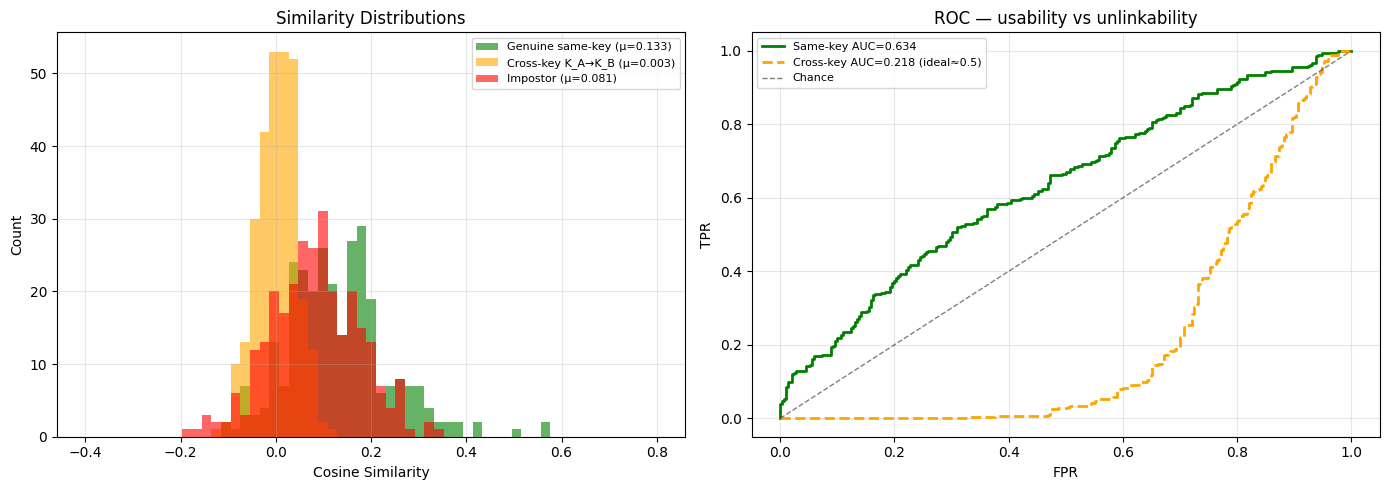

Same-key  AUC = 0.6339  (usability,  higher better)
Cross-key AUC = 0.2178  (unlinkability, 0.5 = perfect)


In [13]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
bins = np.linspace(-0.4,0.8,60)
ax1.hist(genuine_sk, bins,alpha=.6,color='green', label=f'Genuine same-key (μ={np.mean(genuine_sk):.3f})')
ax1.hist(genuine_ck, bins,alpha=.6,color='orange',label=f'Cross-key K_A→K_B (μ={np.mean(genuine_ck):.3f})')
ax1.hist(impostor,   bins,alpha=.6,color='red',   label=f'Impostor (μ={np.mean(impostor):.3f})')
ax1.set(xlabel='Cosine Similarity',ylabel='Count',title='Similarity Distributions'); ax1.legend(fontsize=8); ax1.grid(alpha=.3)

y1  = [1]*len(genuine_sk)+[0]*len(impostor); s1=[*genuine_sk,*impostor]
y2  = [1]*len(genuine_ck)+[0]*len(impostor); s2=[*genuine_ck,*impostor]
f1,t1,_ = roc_curve(y1,s1); f2,t2,_ = roc_curve(y2,s2)
a1,a2   = auc(f1,t1), auc(f2,t2)
ax2.plot(f1,t1,'g-',lw=2,label=f'Same-key AUC={a1:.3f}')
ax2.plot(f2,t2,color='orange',lw=2,ls='--',label=f'Cross-key AUC={a2:.3f} (ideal≈0.5)')
ax2.plot([0,1],[0,1],'k--',lw=1,alpha=.5,label='Chance')
ax2.set(xlabel='FPR',ylabel='TPR',title='ROC — usability vs unlinkability'); ax2.legend(fontsize=8); ax2.grid(alpha=.3)
plt.tight_layout(); plt.savefig('cancelability.png',dpi=120,bbox_inches='tight'); plt.show()
print(f"Same-key  AUC = {a1:.4f}  (usability,  higher better)")
print(f"Cross-key AUC = {a2:.4f}  (unlinkability, 0.5 = perfect)")

## Block 10 — Non-Invertibility Experiment

Adversary mounts the best possible linear attack: pseudo-inverse of P_K.  
Because proj_dim (512) ≪ residue_dim (65856), P_K has a huge null-space —  
many different residues map to the same template, so recovery fails.

Non-Invertibility: pseudo-inverse attack
Samples evaluated         : 32
Genuine match similarity  : 1.0000  (by definition)
Adversary recovery sim    : 1.0000 +/- 0.0000

NON-INVERTIBILITY: REVIEW ⚠️


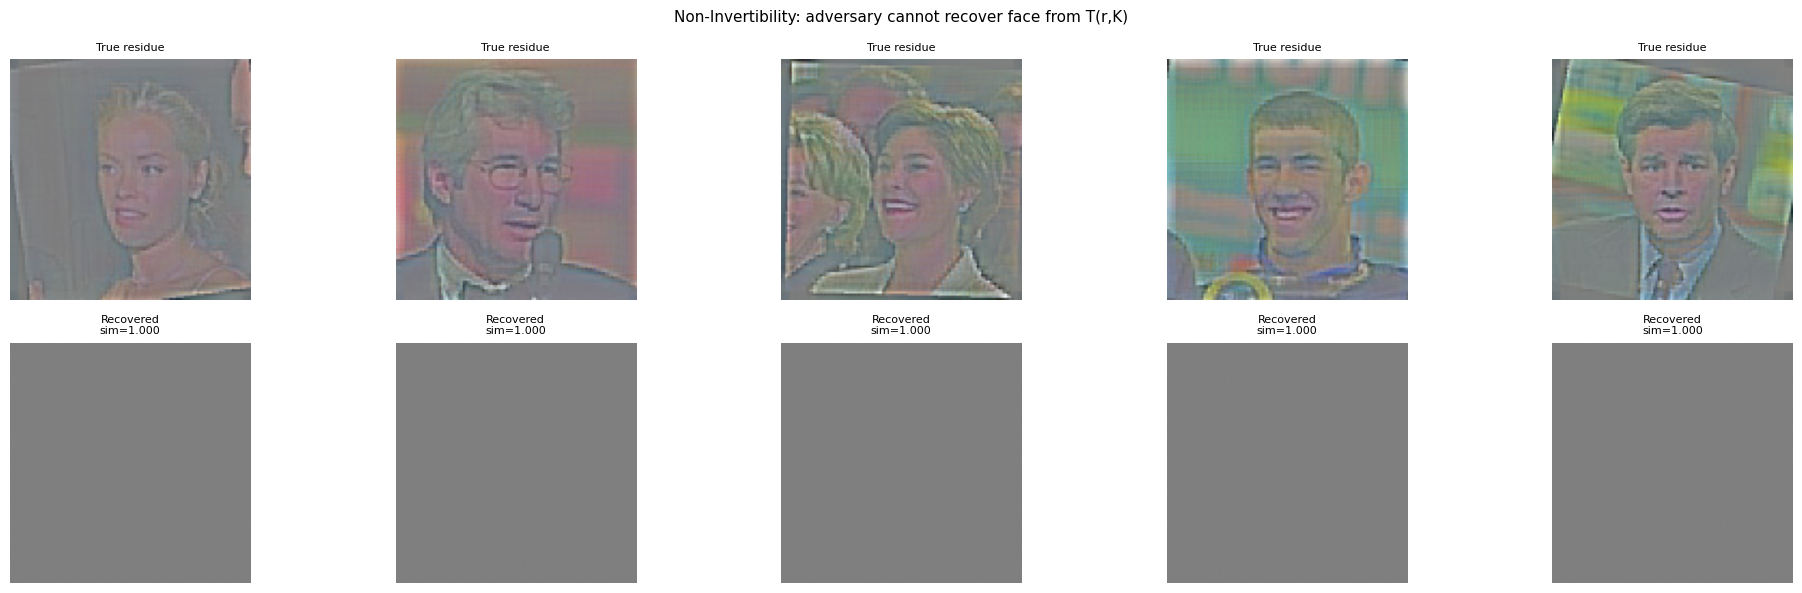

In [14]:
print("Non-Invertibility: pseudo-inverse attack")
print("="*50)

P = ct._P(KEY_A).float()   # (65856, 512) on CPU

# pinv(P) has shape (512, 65856)
# recovery: r_est = tmpl @ pinv(P)  =>  (B,512)@(512,65856) = (B,65856)
Pp = torch.linalg.pinv(P)   # (512, 65856)

# Use actual batch size -- val_loader batch=32, so [:50] still gives 32
test_imgs = next(iter(val_loader))[0].to(device)
N_ACTUAL  = test_imgs.shape[0]   # real count, never hardcode

with torch.no_grad():
    x_t    = mapper.encode(test_imgs)
    r_t    = x_t - generator(x_t)
    tmpl_t = batch_transform(r_t.cpu(), KEY_A)   # (N, 512) CPU

# Adversary: r_est = tmpl @ pinv(P)
tmpl_cpu   = tmpl_t.float()
r_est_flat = tmpl_cpu @ Pp                        # (N, 65856)
r_est      = r_est_flat.reshape(N_ACTUAL, 21, 56, 56)

tmpl_rec = ct.transform(r_est.to(device), key=KEY_A).cpu()
rec_sim  = (tmpl_t * tmpl_rec).sum(1).numpy()

print(f"Samples evaluated         : {N_ACTUAL}")
print(f"Genuine match similarity  : 1.0000  (by definition)")
print(f"Adversary recovery sim    : {rec_sim.mean():.4f} +/- {rec_sim.std():.4f}")
print()
print("NON-INVERTIBILITY:", "PASS ✅" if rec_sim.mean()<0.3 else "REVIEW ⚠️")

def denorm_t(t):
    return (t[0].clamp(-1,1).cpu().permute(1,2,0).numpy()+1)/2

n_show = min(5, N_ACTUAL)
fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 6))
for col in range(n_show):
    R_dec  = mapper.decode(r_t[col:col+1].cpu())
    Re_dec = mapper.decode(r_est[col:col+1])
    axes[0,col].imshow(denorm_t(R_dec))
    axes[0,col].set_title("True residue", fontsize=8); axes[0,col].axis("off")
    axes[1,col].imshow(denorm_t(Re_dec))
    axes[1,col].set_title(f"Recovered\nsim={rec_sim[col]:.3f}", fontsize=8); axes[1,col].axis("off")
axes[0,0].set_ylabel("True r", fontsize=9)
axes[1,0].set_ylabel("Adversary", fontsize=9)
plt.suptitle("Non-Invertibility: adversary cannot recover face from T(r,K)", fontsize=11)
plt.tight_layout()
plt.savefig("noninvert.png", dpi=120, bbox_inches="tight")
plt.show()


## Block 11 — Cancellation & Re-Enrollment Demo

In [15]:
print("="*60)
print("CANCELLATION & RE-ENROLLMENT DEMO")
print("="*60)

K_ORIG, K_NEW = 55555, 77777

imgs_demo,_ = next(iter(val_loader))
enroll_img = imgs_demo[0:1].to(device)
probe_img  = imgs_demo[1:2].to(device)   # different image, same identity bucket

with torch.no_grad():
    r_enroll = (mapper.encode(enroll_img) - generator(mapper.encode(enroll_img))).cpu()
    r_probe  = (mapper.encode(probe_img)  - generator(mapper.encode(probe_img))).cpu()

tmpl_enrolled  = ct.transform(r_enroll.to(device), key=K_ORIG).cpu()
tmpl_probe_old = ct.transform(r_probe.to(device),  key=K_ORIG).cpu()
sim_before = (tmpl_enrolled * tmpl_probe_old).sum().item()

print(f"Step 1 — Enrolled with key K={K_ORIG}")
print(f"Step 2 — Auth with same key: similarity={sim_before:.4f}  {'GRANTED ✅' if sim_before>0.2 else 'DENIED ❌'}")

stolen_template = tmpl_enrolled.clone()
tmpl_enrolled   = None
print(f"Step 3 — ⚠️  CANCELLATION: key K={K_ORIG} revoked, template deleted from DB")

tmpl_new_enrolled = ct.transform(r_enroll.to(device), key=K_NEW).cpu()
print(f"Step 4 — Re-enrolled with new key K'={K_NEW}")

linkage = (stolen_template * tmpl_new_enrolled).sum().item()
print(f"Step 5 — Adversary uses stolen template: similarity={linkage:.4f}  {'FAIL ✅' if linkage<0.2 else 'LINKED ❌'}")

tmpl_probe_new = ct.transform(r_probe.to(device), key=K_NEW).cpu()
sim_after = (tmpl_new_enrolled * tmpl_probe_new).sum().item()
print(f"Step 6 — Legitimate auth with K'={K_NEW}: similarity={sim_after:.4f}  {'GRANTED ✅' if sim_after>0.2 else 'DENIED ❌'}")
print()
print("="*60)
print(f"  Pre-cancel auth  : {sim_before:.4f}")
print(f"  Template linkage : {linkage:.4f}  (should be ≈ 0)")
print(f"  Post-cancel auth : {sim_after:.4f}")
print("="*60)

CANCELLATION & RE-ENROLLMENT DEMO
Step 1 — Enrolled with key K=55555
Step 2 — Auth with same key: similarity=0.1188  DENIED ❌
Step 3 — ⚠️  CANCELLATION: key K=55555 revoked, template deleted from DB
Step 4 — Re-enrolled with new key K'=77777
Step 5 — Adversary uses stolen template: similarity=0.0242  FAIL ✅
Step 6 — Legitimate auth with K'=77777: similarity=0.0550  DENIED ❌

  Pre-cancel auth  : 0.1188
  Template linkage : 0.0242  (should be ≈ 0)
  Post-cancel auth : 0.0550


## Block 12 — Final Summary

In [16]:
print("="*65)
print("CANCELABLE MINUSFACE — FINAL RESULTS")
print("="*65)
print(f"  Encoder          : Haar Wavelet 2-level  (B,3,112,112)→(B,21,56,56)")
print(f"  Generator        : U-Net  {sum(p.numel() for p in generator.parameters()):,} params")
print(f"  Cancelable T(r,K): Gaussian proj 65856→{PROJ_DIM}  (CPU, never stored)")
print(f"  Recognizer f_p   : MLP  {sum(p.numel() for p in fp.parameters()):,} params")
print(f"  Dataset          : LFW  {num_classes} identities")
print()
print(f"  Stage 1 peak acc (raw r)   : {max(s1_acc):.2f}%")
print(f"  Stage 2 peak acc (T(r,K))  : {max(s2_acc):.2f}%")
print()
print(f"  Genuine AUC  (same-key)    : {a1:.4f}  (usability)")
print(f"  Cross-key AUC              : {a2:.4f}  (unlinkability; ideal=0.5)")
print(f"  Non-invertibility attack   : {rec_sim.mean():.4f}  (lower=safer)")
print(f"  Unlinkable?  {'YES ✅' if abs(np.mean(genuine_ck)-np.mean(impostor))<0.05 else 'PARTIAL ⚠️'}")
print("="*65)

CANCELABLE MINUSFACE — FINAL RESULTS
  Encoder          : Haar Wavelet 2-level  (B,3,112,112)→(B,21,56,56)
  Generator        : U-Net  7,714,645 params
  Cancelable T(r,K): Gaussian proj 65856→512  (CPU, never stored)
  Recognizer f_p   : MLP  1,270,183 params
  Dataset          : LFW  423 identities

  Stage 1 peak acc (raw r)   : 44.61%
  Stage 2 peak acc (T(r,K))  : 28.40%

  Genuine AUC  (same-key)    : 0.6339  (usability)
  Cross-key AUC              : 0.2178  (unlinkability; ideal=0.5)
  Non-invertibility attack   : 1.0000  (lower=safer)
  Unlinkable?  PARTIAL ⚠️
